In [48]:
import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.figure_factory as ff

from collections import Counter
from wordcloud import WordCloud
from plotly.subplots import make_subplots
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = pd.DataFrame()

In [49]:
apps = ["Facebook", "Instagram", "Skype", "Snapchat", "TikTok", "Twitter", "Viber", "WhatsApp", "Netflix", "Flipboard"]

for app in apps:
    app_df = pd.read_csv(f"files/{app}.csv")
    app_df['app'] = app
    df = pd.concat([df, app_df], ignore_index=True)

In [50]:
df.head(15)

,reviewId,content,score,app
0,437c0830-9a0e-4005-b13b-c4c03c4ef06c,It helps me communicate w my kids,5,Facebook
1,db6c59ec-2755-4ead-bc84-2fba101d71f0,Ok,4,Facebook
2,9700fff2-022e-42d8-998a-39f3f8500f51,Good app 👌,5,Facebook
3,bc746c52-1732-4def-a5c2-dc7682677b1b,Great but i cant download,5,Facebook
4,babe5691-4994-48d8-bd91-95fd55b7fe07,very nice,5,Facebook
5,3297b164-80f5-4f05-a419-1b71e3be9988,𝑽𝒆𝒓𝒚 𝒏𝒊𝒄𝒆,5,Facebook
6,c3dbabad-32f0-4d4a-bcd7-e047d26c0c10,MD.shahid,5,Facebook
7,04d86224-533a-4dcd-aa07-3057da35a4c7,I'm single,2,Facebook
8,152a9a2f-ac12-40fb-a222-095e5cf10ce6,walang kwenta,1,Facebook
9,c19a6559-902f-4145-85e6-0fc6fce5ed43,হাই,5,Facebook


In [51]:
df.describe()

,score
count,100000.000000
mean,3.614140
std,1.726152
min,1.000000
25%,1.000000
50%,5.000000
75%,5.000000
max,5.000000


In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 4 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   reviewId  100000 non-null  object
 1   content   99987 non-null   object
 2   score     100000 non-null  int64 
 3   app       100000 non-null  object
dtypes: int64(1), object(3)
memory usage: 3.1+ MB


In [53]:
df = df.dropna()

In [54]:
import re
import string
import unicodedata
from cleantext import clean

def normalize_font(text):
    return unicodedata.normalize('NFKD', text).encode('ascii', 'ignore').decode('utf-8', 'ignore')

def remove_emoji(text):
    return clean(text)

def clean_text(text):
    text = normalize_font(text)
    text = remove_emoji(text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    return text

In [55]:
df['cleaned_content'] = df['content'].apply(clean_text)

In [56]:
df = df[df['cleaned_content'] != '']

In [57]:
df.head(15)

,reviewId,content,score,app,cleaned_content
0,437c0830-9a0e-4005-b13b-c4c03c4ef06c,It helps me communicate w my kids,5,Facebook,it helps me communicate w my kids
1,db6c59ec-2755-4ead-bc84-2fba101d71f0,Ok,4,Facebook,ok
2,9700fff2-022e-42d8-998a-39f3f8500f51,Good app 👌,5,Facebook,good app
3,bc746c52-1732-4def-a5c2-dc7682677b1b,Great but i cant download,5,Facebook,great but i cant download
4,babe5691-4994-48d8-bd91-95fd55b7fe07,very nice,5,Facebook,very nice
5,3297b164-80f5-4f05-a419-1b71e3be9988,𝑽𝒆𝒓𝒚 𝒏𝒊𝒄𝒆,5,Facebook,very nice
6,c3dbabad-32f0-4d4a-bcd7-e047d26c0c10,MD.shahid,5,Facebook,mdshahid
7,04d86224-533a-4dcd-aa07-3057da35a4c7,I'm single,2,Facebook,im single
8,152a9a2f-ac12-40fb-a222-095e5cf10ce6,walang kwenta,1,Facebook,walang kwenta
10,05c3a117-6c82-416d-b59a-237346979e6a,Round,5,Facebook,round


In [58]:
df["content_leght"] = df['content'].apply(len)

In [59]:
df.head(15)

,reviewId,content,score,app,cleaned_content,content_leght
0,437c0830-9a0e-4005-b13b-c4c03c4ef06c,It helps me communicate w my kids,5,Facebook,it helps me communicate w my kids,33
1,db6c59ec-2755-4ead-bc84-2fba101d71f0,Ok,4,Facebook,ok,2
2,9700fff2-022e-42d8-998a-39f3f8500f51,Good app 👌,5,Facebook,good app,10
3,bc746c52-1732-4def-a5c2-dc7682677b1b,Great but i cant download,5,Facebook,great but i cant download,25
4,babe5691-4994-48d8-bd91-95fd55b7fe07,very nice,5,Facebook,very nice,9
5,3297b164-80f5-4f05-a419-1b71e3be9988,𝑽𝒆𝒓𝒚 𝒏𝒊𝒄𝒆,5,Facebook,very nice,9
6,c3dbabad-32f0-4d4a-bcd7-e047d26c0c10,MD.shahid,5,Facebook,mdshahid,9
7,04d86224-533a-4dcd-aa07-3057da35a4c7,I'm single,2,Facebook,im single,10
8,152a9a2f-ac12-40fb-a222-095e5cf10ce6,walang kwenta,1,Facebook,walang kwenta,13
10,05c3a117-6c82-416d-b59a-237346979e6a,Round,5,Facebook,round,5


In [60]:
fig = make_subplots(rows=2, cols=5, subplot_titles=df['app'].unique())

for i, app in enumerate(df['app'].unique(), 1):
    row = (i - 1) // 5 + 1
    col = (i - 1) % 5 + 1
    
    app_data = df[df['app'] == app]
    
    fig.add_trace(go.Box(y=app_data['content_leght'], name='Boxplot', boxmean=True, boxpoints='outliers'), row=row, col=col)
    
fig.update_layout(title='Content Length Distribution by App', showlegend=False)
fig.update_xaxes(title_text='Content Length', row=2, col=3)
fig.update_yaxes(title_text='Count', row=1, col=1)
fig.update_layout(width=800, height=600)

fig.show()

In [61]:
fig = make_subplots(rows=2, cols=5, subplot_titles=df['app'].unique())

for i, app in enumerate(df['app'].unique(), 1):
    row = (i - 1) // 5 + 1
    col = (i - 1) % 5 + 1
    
    app_data = df[df['app'] == app]
    
    fig.add_trace(go.Histogram(x=app_data['score'], name='Histogram'), row=row, col=col)
    
fig.update_layout(title='Score Distribution by App', showlegend=False)
fig.update_xaxes(title_text='score', row=2, col=3)
fig.update_yaxes(title_text='Count', row=1, col=1)
fig.update_layout(width=1000, height=600)

fig.show()

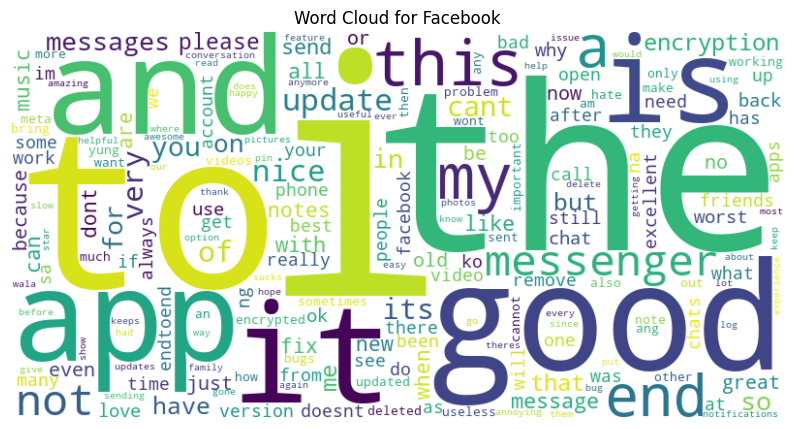

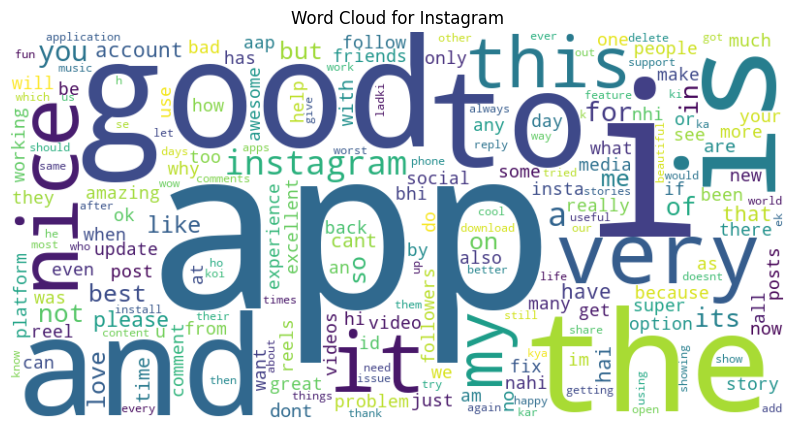

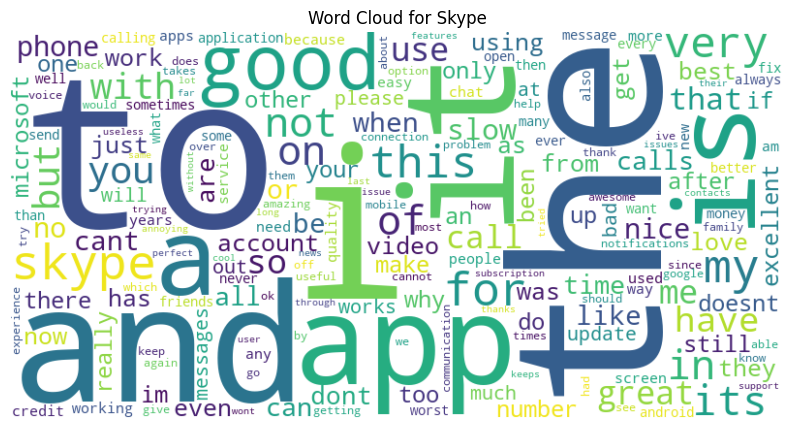

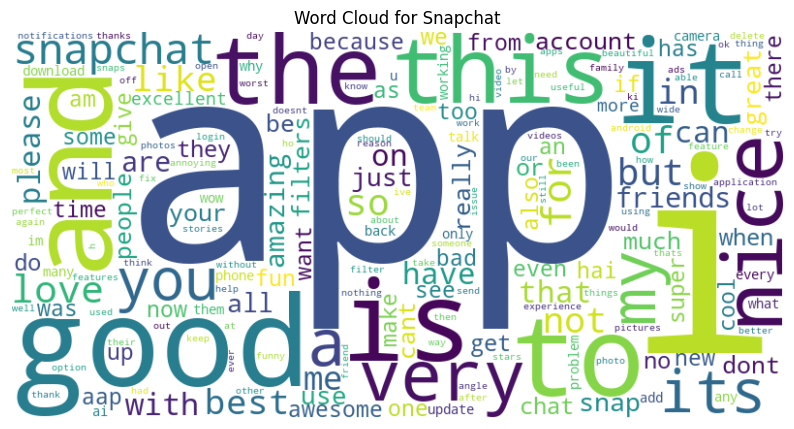

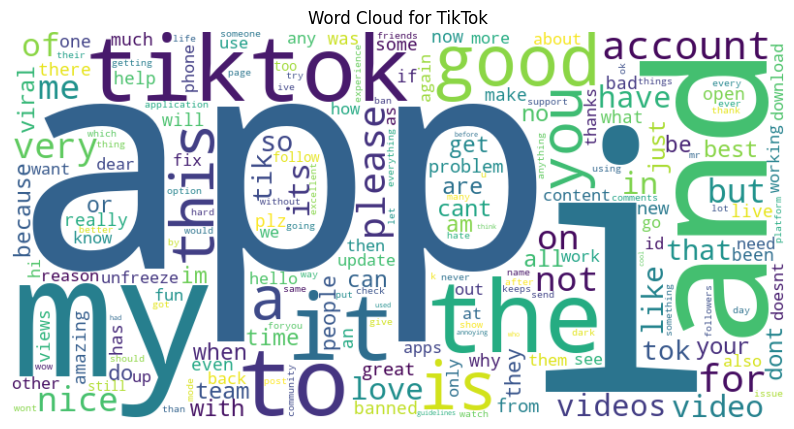

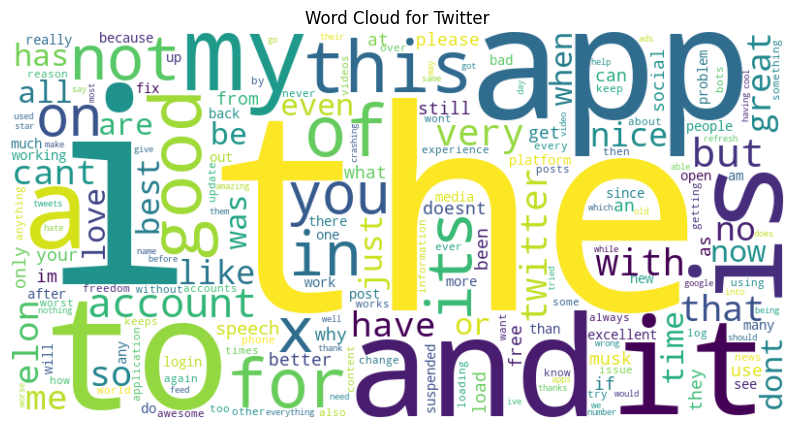

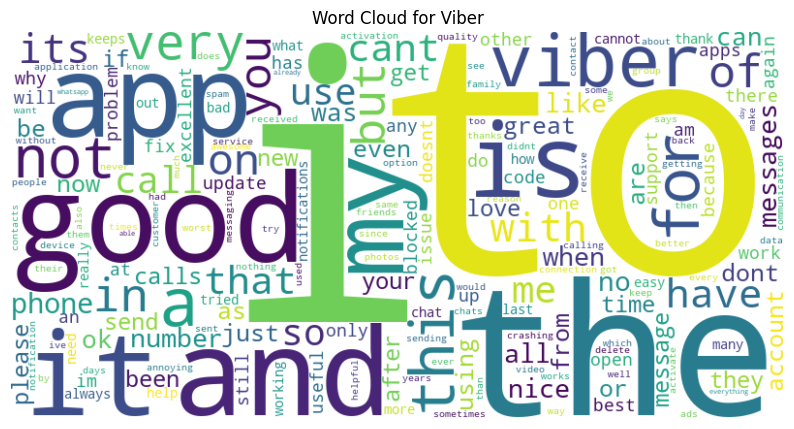

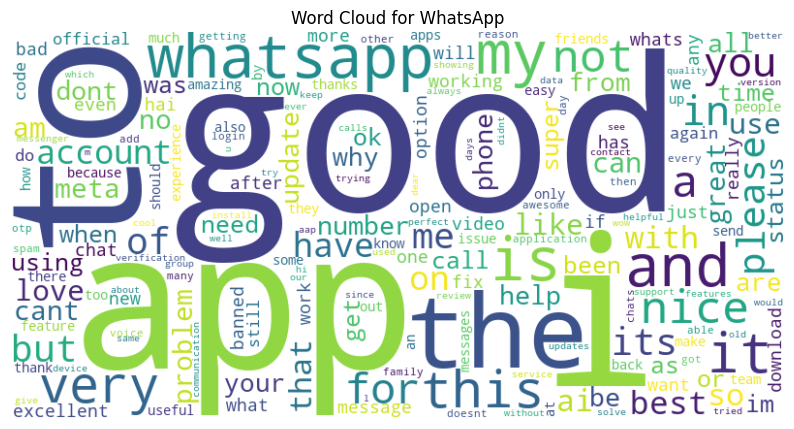

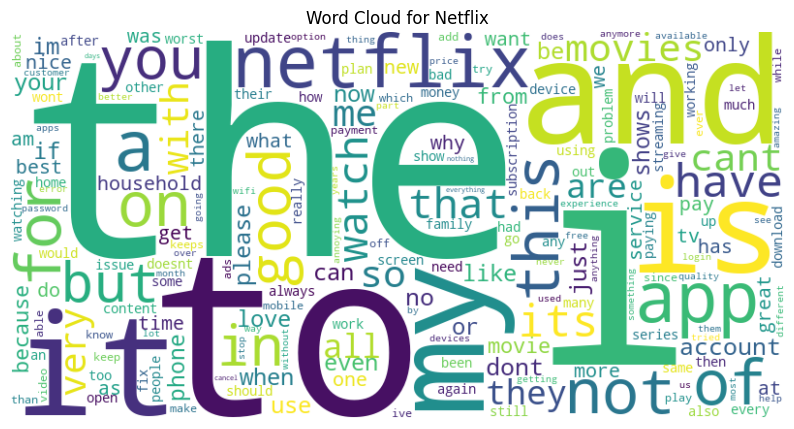

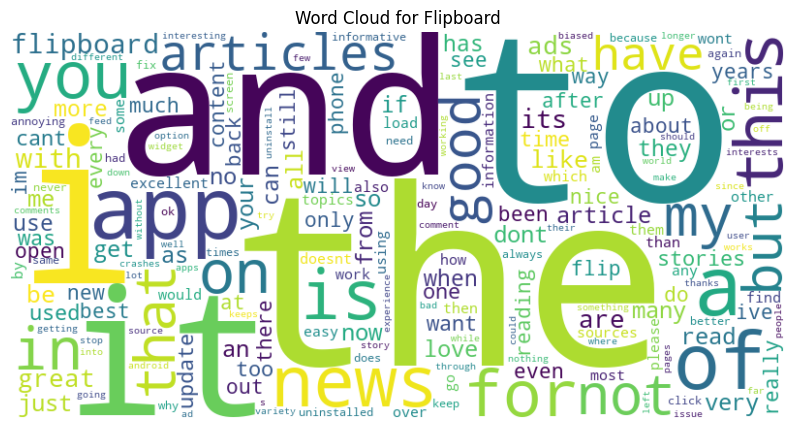

In [62]:
word_counts_per_app = {}

for app in df['app'].unique():
    app_data = df[df['app'] == app]
    
    all_text = ' '.join(app_data['cleaned_content'])
    
    word_count = Counter(all_text.split())
    
    word_counts_per_app[app] = word_count
    
for app_name, word_counter in word_counts_per_app.items():
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word_counter)
    
    plt.figure(figsize=(10, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(f'Word Cloud for {app_name}')
    plt.axis('off')
    plt.show()

In [63]:
df.head(20)

,reviewId,content,score,app,cleaned_content,content_leght
0,437c0830-9a0e-4005-b13b-c4c03c4ef06c,It helps me communicate w my kids,5,Facebook,it helps me communicate w my kids,33
1,db6c59ec-2755-4ead-bc84-2fba101d71f0,Ok,4,Facebook,ok,2
2,9700fff2-022e-42d8-998a-39f3f8500f51,Good app 👌,5,Facebook,good app,10
3,bc746c52-1732-4def-a5c2-dc7682677b1b,Great but i cant download,5,Facebook,great but i cant download,25
4,babe5691-4994-48d8-bd91-95fd55b7fe07,very nice,5,Facebook,very nice,9
5,3297b164-80f5-4f05-a419-1b71e3be9988,𝑽𝒆𝒓𝒚 𝒏𝒊𝒄𝒆,5,Facebook,very nice,9
6,c3dbabad-32f0-4d4a-bcd7-e047d26c0c10,MD.shahid,5,Facebook,mdshahid,9
7,04d86224-533a-4dcd-aa07-3057da35a4c7,I'm single,2,Facebook,im single,10
8,152a9a2f-ac12-40fb-a222-095e5cf10ce6,walang kwenta,1,Facebook,walang kwenta,13
10,05c3a117-6c82-416d-b59a-237346979e6a,Round,5,Facebook,round,5


In [64]:
df_sample = df.sample(n=10000, random_state=42)
df_sample.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 16831 to 39407
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   reviewId         10000 non-null  object
 1   content          10000 non-null  object
 2   score            10000 non-null  int64 
 3   app              10000 non-null  object
 4   cleaned_content  10000 non-null  object
 5   content_leght    10000 non-null  int64 
dtypes: int64(2), object(4)
memory usage: 546.9+ KB


Не используя sklearn

In [65]:
import statsmodels.api as sm
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import LabelBinarizer
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()
X = tfidf.fit_transform(df_sample['cleaned_content'])

label_binarizer = LabelBinarizer()
y = label_binarizer.fit_transform(df_sample['score'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [66]:
from scipy.sparse import csr_matrix

if isinstance(X_train, csr_matrix):
    X_train = X_train.toarray()
if isinstance(X_test, csr_matrix):
    X_test = X_test.toarray()

In [67]:
def logistic_regression(X, y, learning_rate=0.01, epochs=100):
    n_samples, n_features = X.shape
    w0 = np.zeros(1)
    w1 = np.zeros(n_features)

    for epoch in range(epochs):
        linear_model = w0 + np.dot(X, w1)
        y_pred = 1 / (1 + np.exp(-linear_model))

        dw0 = np.sum(y_pred - y) / n_samples
        dw1 = np.dot(X.T, (y_pred - y)) / n_samples

        w0 -= learning_rate * dw0
        w1 -= learning_rate * dw1

    return w0, w1

In [68]:
predictions = pd.DataFrame()

for i, class_label in enumerate(range(y_train.shape[1])):
    y_train_i = y_train[:, i]
    w0, w1 = logistic_regression(X_train, y_train_i)
    
    linear_model = w0 + np.dot(X_test, w1)
    y_pred = 1 / (1 + np.exp(-linear_model))
    
    predictions[class_label] = y_pred

In [69]:
y_pred = np.argmax(predictions, axis=1).astype(int)
y_test = y_test.argmax(axis=1)

In [70]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=1)
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1: {f1}")

Accuracy: 0.536
Precision: 0.7512960000000001
Recall: 0.536
F1: 0.3740833333333334


Используя sklearn

In [71]:
import statsmodels.api as sm
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import LabelBinarizer
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()
X = tfidf.fit_transform(df_sample['cleaned_content'])

label_binarizer = LabelBinarizer()
y = label_binarizer.fit_transform(df_sample['score'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [72]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

model = LogisticRegression(multi_class='ovr', solver='lbfgs', max_iter=1000)

y_train_flat = np.argmax(y_train, axis=1)
model.fit(X_train, y_train_flat)

y_pred = model.predict(X_test)

y_test = y_test.argmax(axis=1)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=1)
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1: {f1}")

Accuracy: 0.6945
Precision: 0.7228334701777023
Recall: 0.6945
F1: 0.6182980750353563
